# Imports

In [28]:
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst

from astropy import units as u
from astropy.time import Time

import matplotlib.pyplot as plt
import numpy as np 

import os
import urllib.request

import pandas as pd
import datetime as dt

from scipy.stats import norm
import seaborn as sns

import polars as pl

# uncomment line below to see what datasets are available to query from the CDAWeb
a.cdaweb.Dataset('OMNI_HRO2_1MIN')#wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

<sunpy.net.cdaweb.attrs.Dataset(OMNI_HRO2_1MIN: OMNI Combined, Definitive 1-minute IMF and
Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices -
J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)) object at 0x795ea50096d0>

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Date ranges

In [3]:
# Cycle 23 Min # 1 Dec 95 - 30 Nov 96 as Cycle 23 min
startDateC23Min = "1995-12-01 00:00"
endDateC23Min = "1996-11-30 23:59"
DateRangeC23Min = pd.date_range(startDateC23Min, endDateC23Min, freq='MS').strftime("%Y%m%d").tolist()

# Cycle 23 Max # 1 Oct 99 - 30 Sept 00 as Cycle 23 max
startDateC23Max = "1999-10-01 00:00"
endDateC23Max = "2000-09-30 23:59"
DateRangeC23Max = pd.date_range(startDateC23Max, endDateC23Max, freq='MS').strftime("%Y%m%d").tolist()

# Cycle 24 Min # 1 Aug 07 - 31 July 08 as Cycle 24 min
startDateC24Min = "2007-08-01 00:00"
endDateC24Min = "2008-07-31 23:59"
DateRangeC24Min = pd.date_range(startDateC24Min, endDateC24Min, freq='MS').strftime("%Y%m%d").tolist()

# Cycle 24 Max # 1 Nov 13 - 31 Oct 14 as Cycle 24 max
startDateC24Max = "2013-11-01 00:00"
endDateC24Max = "2014-10-31 23:59"
DateRangeC24Max = pd.date_range(startDateC24Max, endDateC24Max, freq='MS').strftime("%Y%m%d").tolist()

# OMNI Data

## Find data in files

In [4]:
directory = "./omniData/"
files_OMNIC23Min = []
files_OMNIC23Max = []
files_OMNIC24Min = []
files_OMNIC24Max = []
for file in os.listdir(directory):
    filename = os.fsdecode(file)
    for j in range(len(DateRangeC23Min)):
        if filename.startswith("omni_hro2_1min_" + str(DateRangeC23Min[j])):
            files_OMNIC23Min.append(directory+filename)
            continue
    for j in range(len(DateRangeC23Max)):
        if filename.startswith("omni_hro2_1min_" + str(DateRangeC23Max[j])):
            files_OMNIC23Max.append(directory+filename)
            continue
    for j in range(len(DateRangeC24Min)):
        if filename.startswith("omni_hro2_1min_" + str(DateRangeC24Min[j])):
            files_OMNIC24Min.append(directory+filename)
            continue
    for j in range(len(DateRangeC24Max)):
        if filename.startswith("omni_hro2_1min_" + str(DateRangeC24Max[j])):
            files_OMNIC24Max.append(directory+filename)
            continue

def myFunc(e):
  return e.split("_")[3]

# C23Min
files_OMNIC23MinSorted = sorted(files_OMNIC23Min, key=myFunc)
# print(files_OMNIC23MinSorted)
OMNIC23Min = TimeSeries(files_OMNIC23MinSorted, concatenate=True)

# C23Max
files_OMNIC23MaxSorted = sorted(files_OMNIC23Max, key=myFunc)
# print(files_OMNIC23MaxSorted)
OMNIC23Max = TimeSeries(files_OMNIC23MaxSorted, concatenate=True)

# C24Min
files_OMNIC24MinSorted = sorted(files_OMNIC24Min, key=myFunc)
# print(files_OMNIC24MinSorted)
OMNIC24Min = TimeSeries(files_OMNIC24MinSorted, concatenate=True)

# C24Max
files_OMNIC24MaxSorted = sorted(files_OMNIC24Max, key=myFunc)
# print(files_OMNIC24MaxSorted)
OMNIC24Max = TimeSeries(files_OMNIC24MaxSorted, concatenate=True)

In [5]:
# C23Min
# OMNIC23Min.columns


## Get TotVsw and plot data to check by eye if it's what you expect

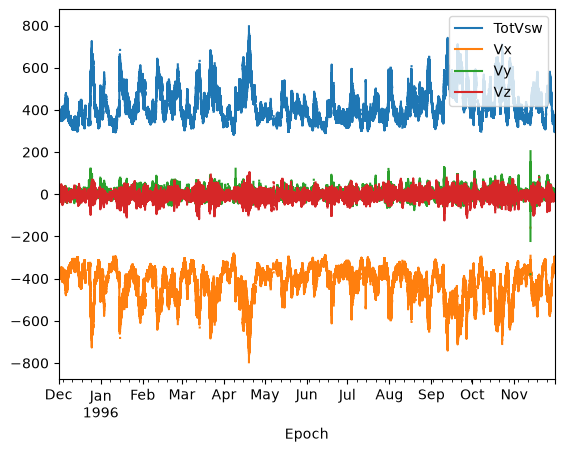

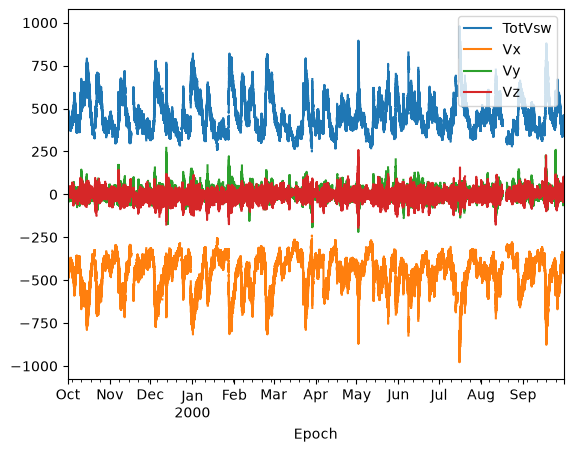

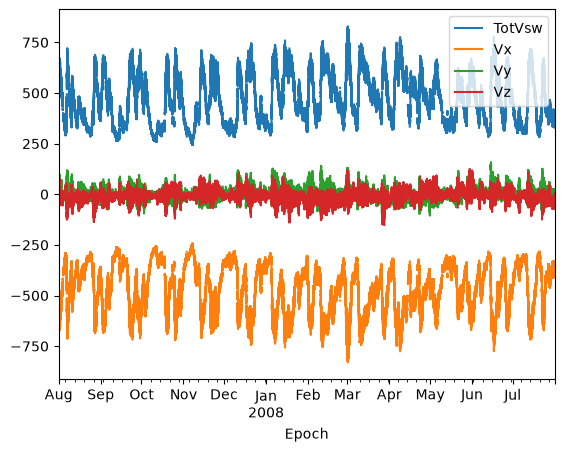

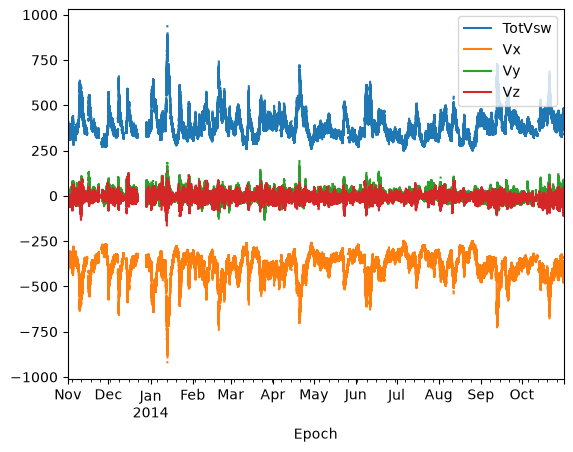

In [6]:
# C23Min

# Combine the components of solar wind speed from data to get total solar wind speed

TotVsw = np.sqrt(OMNIC23Min._data["Vx"]**2 + 
                               OMNIC23Min._data["Vy"]**2 + 
                               OMNIC23Min._data["Vz"]**2)
OMNIC23Min = OMNIC23Min.add_column("TotVsw", TotVsw)

fig, ax = plt.subplots()
OMNIC23Min.plot(columns=["TotVsw", "Vx", "Vy", "Vz"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)
# print(OMNIC23Min._data[""].unique())


# C23Max
TotVsw = np.sqrt(OMNIC23Max._data["Vx"]**2 + 
                               OMNIC23Max._data["Vy"]**2 + 
                               OMNIC23Max._data["Vz"]**2)
OMNIC23Max = OMNIC23Max.add_column("TotVsw", TotVsw)

fig, ax = plt.subplots()
OMNIC23Max.plot(columns=["TotVsw", "Vx", "Vy", "Vz"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)


# C24Min
TotVsw = np.sqrt(OMNIC24Min._data["Vx"]**2 + 
                               OMNIC24Min._data["Vy"]**2 + 
                               OMNIC24Min._data["Vz"]**2)
OMNIC24Min = OMNIC24Min.add_column("TotVsw", TotVsw)

fig, ax = plt.subplots()
OMNIC24Min.plot(columns=["TotVsw", "Vx", "Vy", "Vz"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)


# C24Max
TotVsw = np.sqrt(OMNIC24Max._data["Vx"]**2 + 
                               OMNIC24Max._data["Vy"]**2 + 
                               OMNIC24Max._data["Vz"]**2)
OMNIC24Max = OMNIC24Max.add_column("TotVsw", TotVsw)

fig, ax = plt.subplots()
OMNIC24Max.plot(columns=["TotVsw", "Vx", "Vy", "Vz"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)

## BMag calculated

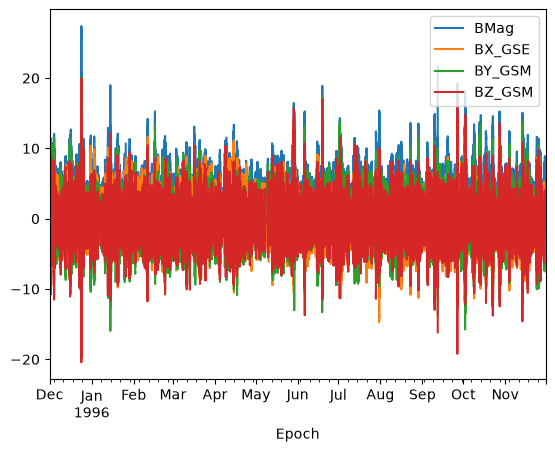

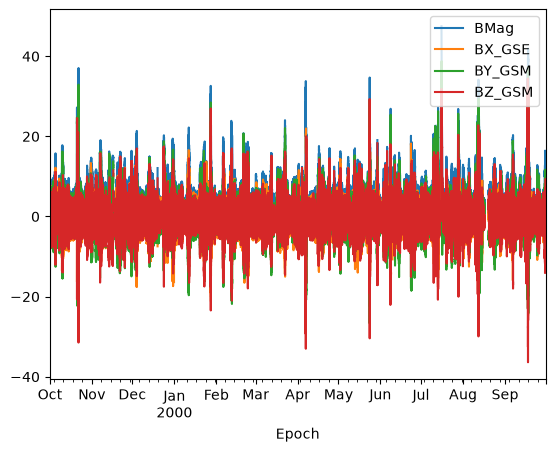

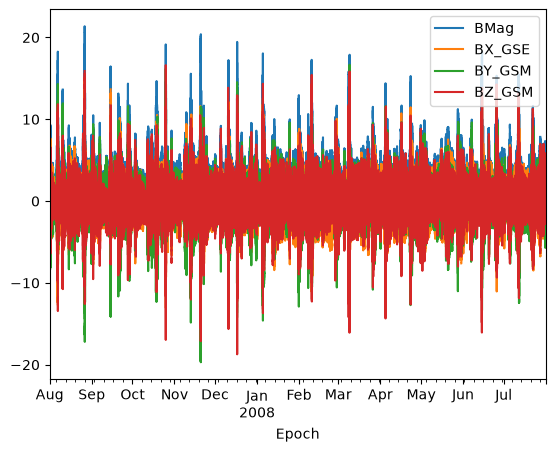

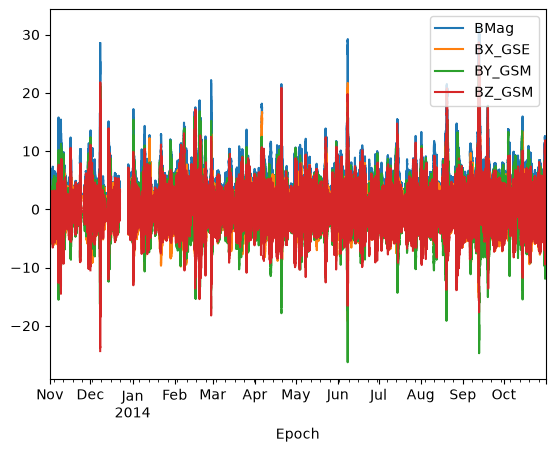

In [48]:
## Get BMag and plot data to check by eye if it's what you expect
# C23Min

# Combine the components of magnetic field from data to get magnitude of magnetic field

BMag = np.sqrt(OMNIC23Min._data["BX_GSE"]**2 + 
                               OMNIC23Min._data["BY_GSM"]**2 + 
                               OMNIC23Min._data["BZ_GSM"]**2)
OMNIC23Min = OMNIC23Min.add_column("BMag", BMag)

fig, ax = plt.subplots()
OMNIC23Min.plot(columns=["BMag", "BX_GSE", "BY_GSM", "BZ_GSM"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)
# print(OMNIC23Min._data[""].unique())


# C23Max
BMag = np.sqrt(OMNIC23Max._data["BX_GSE"]**2 + 
                               OMNIC23Max._data["BY_GSM"]**2 + 
                               OMNIC23Max._data["BZ_GSM"]**2)
OMNIC23Max = OMNIC23Max.add_column("BMag", BMag)

fig, ax = plt.subplots()
OMNIC23Max.plot(columns=["BMag", "BX_GSE", "BY_GSM", "BZ_GSM"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)


# C24Min
BMag = np.sqrt(OMNIC24Min._data["BX_GSE"]**2 + 
                               OMNIC24Min._data["BY_GSM"]**2 + 
                               OMNIC24Min._data["BZ_GSM"]**2)
OMNIC24Min = OMNIC24Min.add_column("BMag", BMag)

fig, ax = plt.subplots()
OMNIC24Min.plot(columns=["BMag", "BX_GSE", "BY_GSM", "BZ_GSM"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)


# C24Max
BMag = np.sqrt(OMNIC24Max._data["BX_GSE"]**2 + 
                               OMNIC24Max._data["BY_GSM"]**2 + 
                               OMNIC24Max._data["BZ_GSM"]**2)
OMNIC24Max = OMNIC24Max.add_column("BMag", BMag)

fig, ax = plt.subplots()
OMNIC24Max.plot(columns=["BMag", "BX_GSE", "BY_GSM", "BZ_GSM"])
plt.legend(loc="upper right")
# plt.ylim(-450,900)

## Dotted plots for extra checks

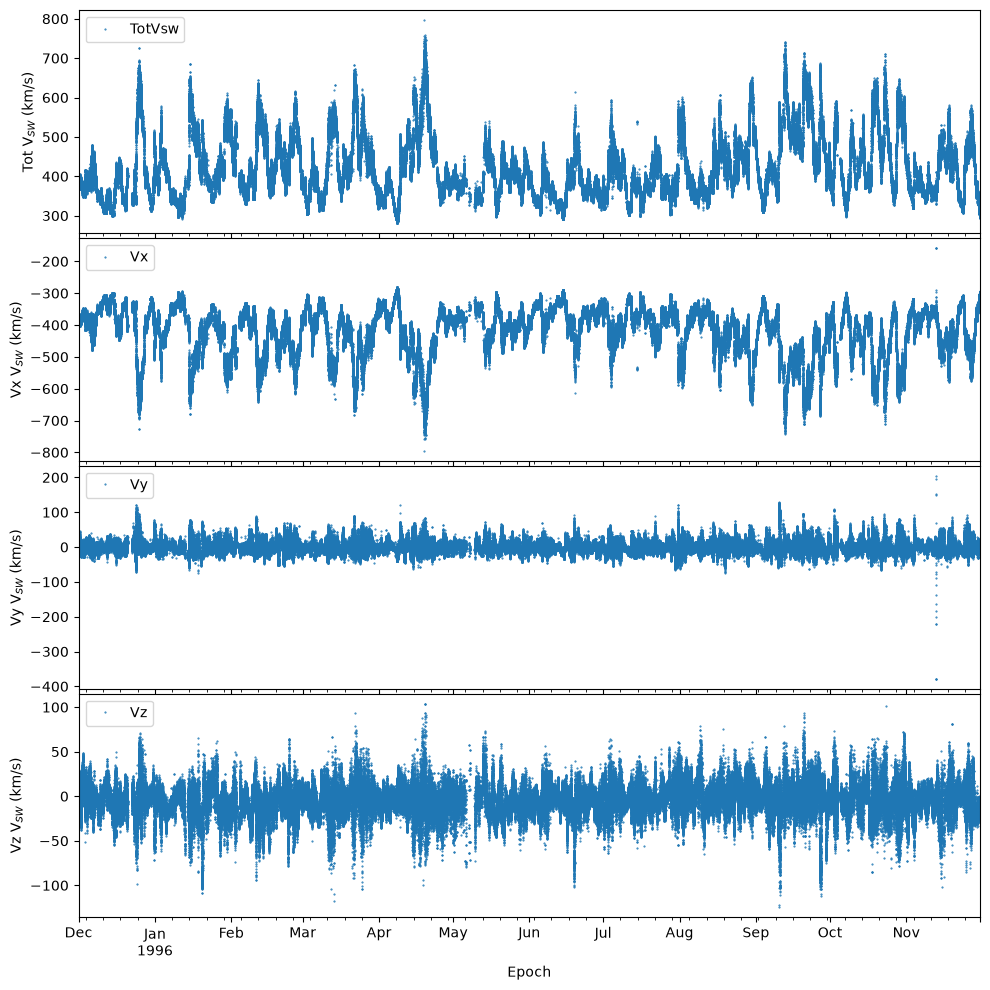

In [49]:
# Code for dotted plots
fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))

# total OMNI speed
OMNIC23Min._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
# plt.axhline(400, ls="dashed")

# components of OMNI speed
OMNIC23Min._data["Vx"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
ax[1].set_ylabel("Vx V$_{SW}$ (km/s)")

# components of OMNI speed
OMNIC23Min._data["Vy"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
ax[2].set_ylabel("Vy V$_{SW}$ (km/s)")

# components of OMNI speed
OMNIC23Min._data["Vz"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar OMNI is mostly radial/along the Parker spiral
ax[3].set_ylabel("Vz V$_{SW}$ (km/s)")

for aa in ax:
    aa.legend(loc="upper left")
    # aa.axvline("2022-01-29 00:00", color='k')
    # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
    # aa.set_ylim(-400,400)

# ax[0].set_xlim(psp_spc.time[0].datetime, psp_spc.time[-1].datetime)
# ax[4].set_xlabel("Time")
plt.tight_layout()
plt.subplots_adjust(hspace=0.02)

## Histograms

### All together histograms

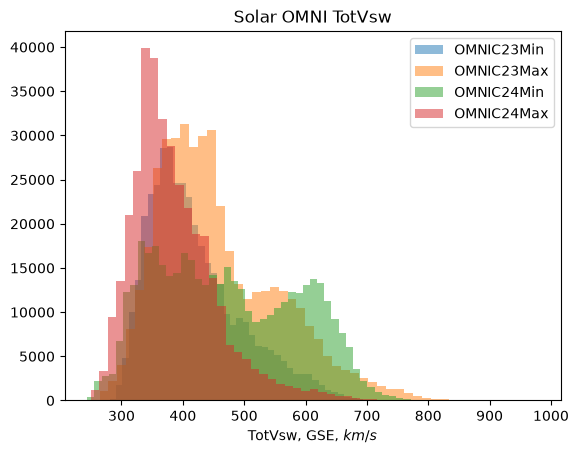

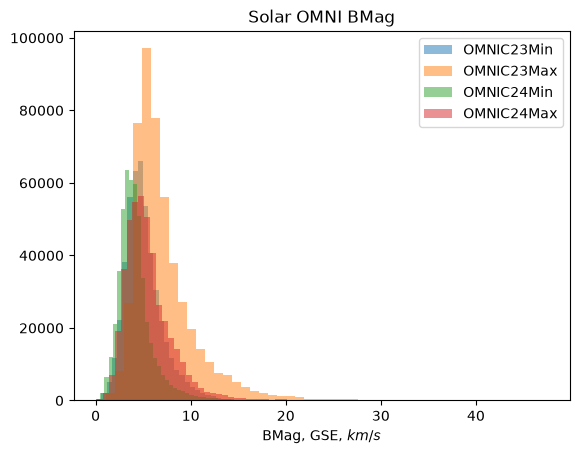

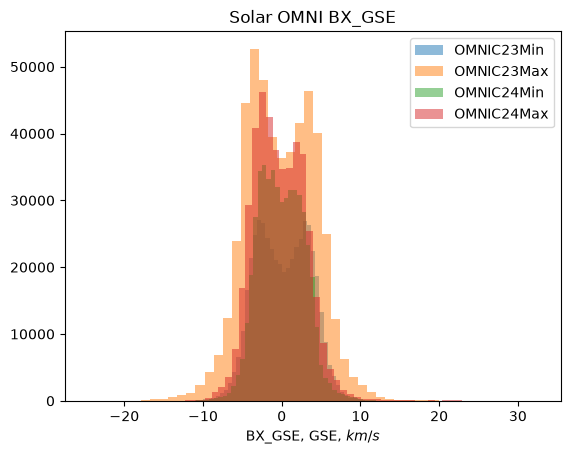

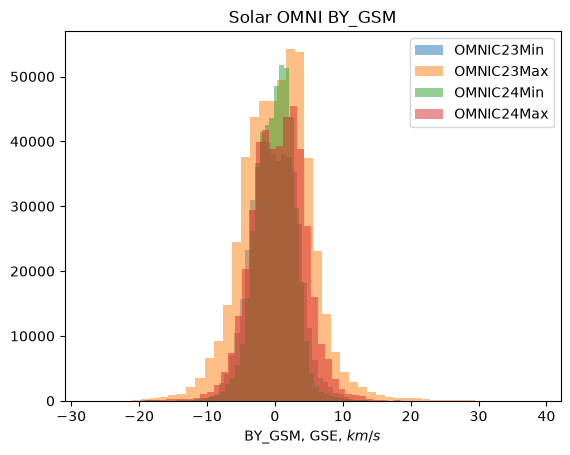

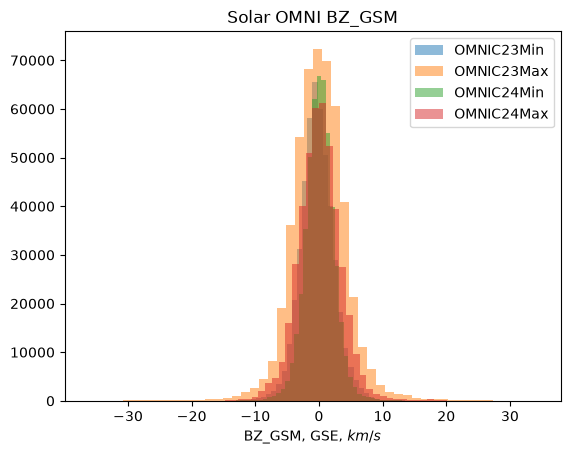

In [51]:
# Histogram formatting - all together
Bin = 50
Alpha = 0.5
Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM", "BZ_GSM"]

for i in range(len(Plotting)):
    plt.hist(OMNIC23Min._data[Plotting[i]], bins = Bin, label = "OMNIC23Min", alpha = Alpha)
    plt.hist(OMNIC23Max._data[Plotting[i]], bins = Bin, label = "OMNIC23Max", alpha = Alpha)
    plt.hist(OMNIC24Min._data[Plotting[i]], bins = Bin, label = "OMNIC24Min", alpha = Alpha)
    plt.hist(OMNIC24Max._data[Plotting[i]], bins = Bin, label = "OMNIC24Max", alpha = Alpha)
    plt.title("Solar OMNI " + Plotting[i])
    plt.xlabel(Plotting[i] + r", GSE, $km/s$")
    plt.legend()
    plt.show()

# plt.hist(OMNIC23Min._data["BY_GSM"], bins = Bin, label = "OMNIC23Min", alpha = Alpha)
# plt.hist(OMNIC23Max._data["BY_GSM"], bins = Bin, label = "OMNIC23Max", alpha = Alpha)
# plt.hist(OMNIC24Min._data["BY_GSM"], bins = Bin, label = "OMNIC24Min", alpha = Alpha)
# plt.hist(OMNIC24Max._data["BY_GSM"], bins = Bin, label = "OMNIC24Max", alpha = Alpha)
# plt.title("Magnetic field")
# plt.xlabel(r"By, GSM, $nT$")
# plt.legend()
# plt.show()

### Separate histograms

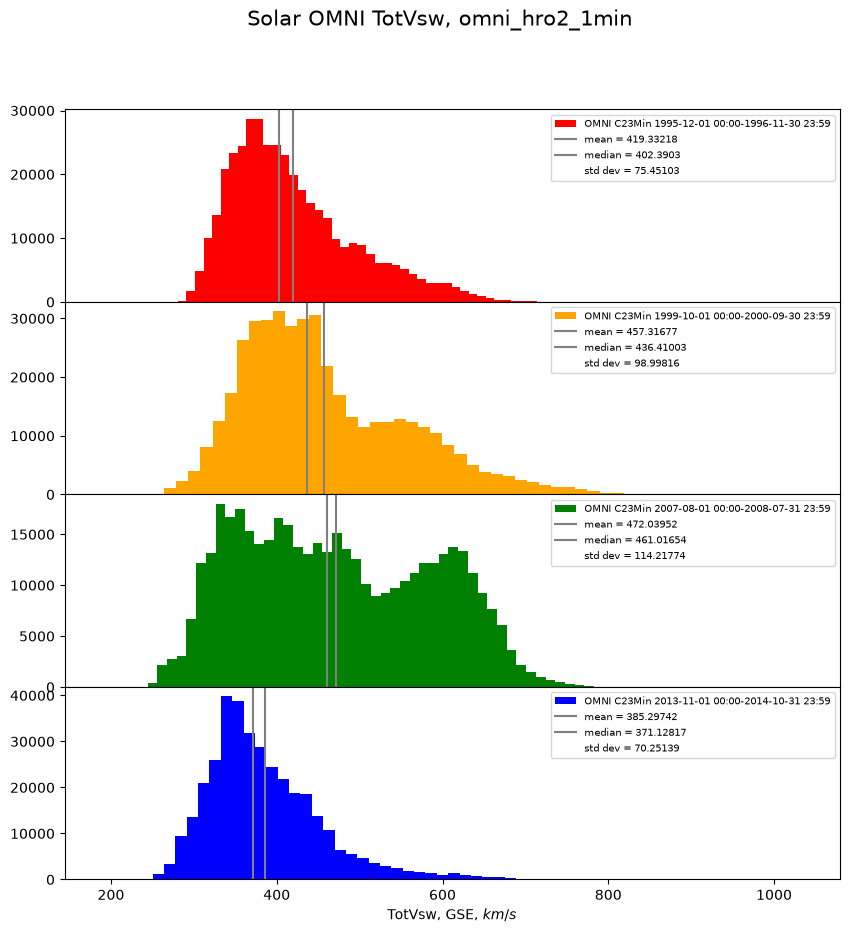

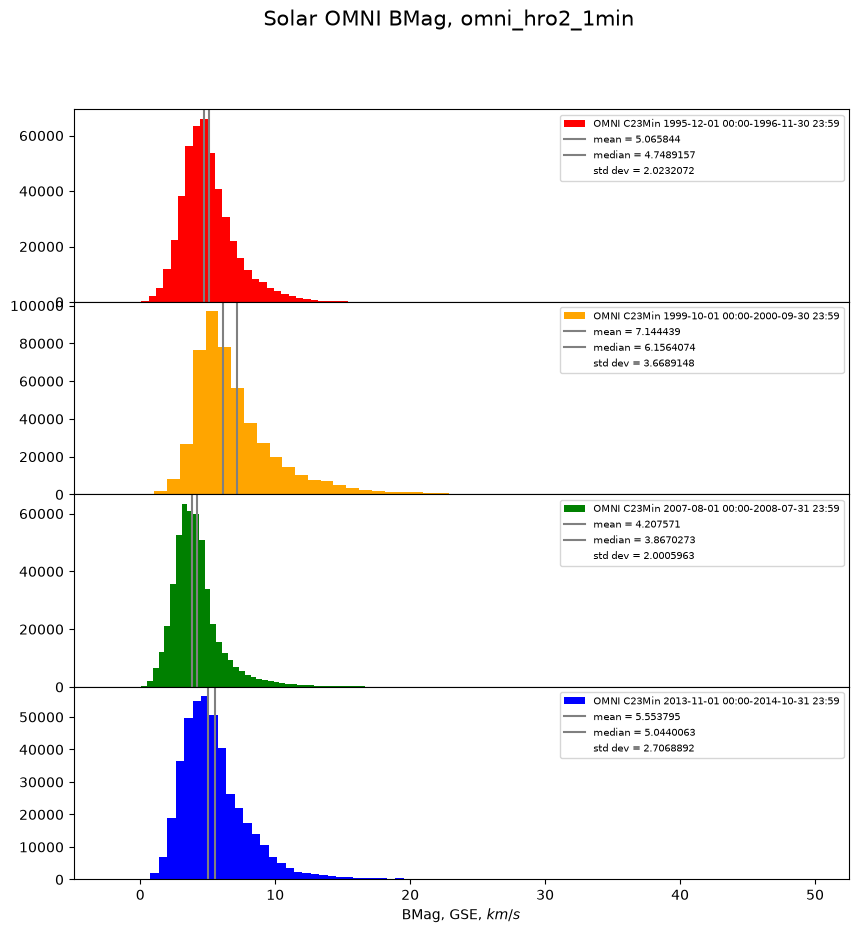

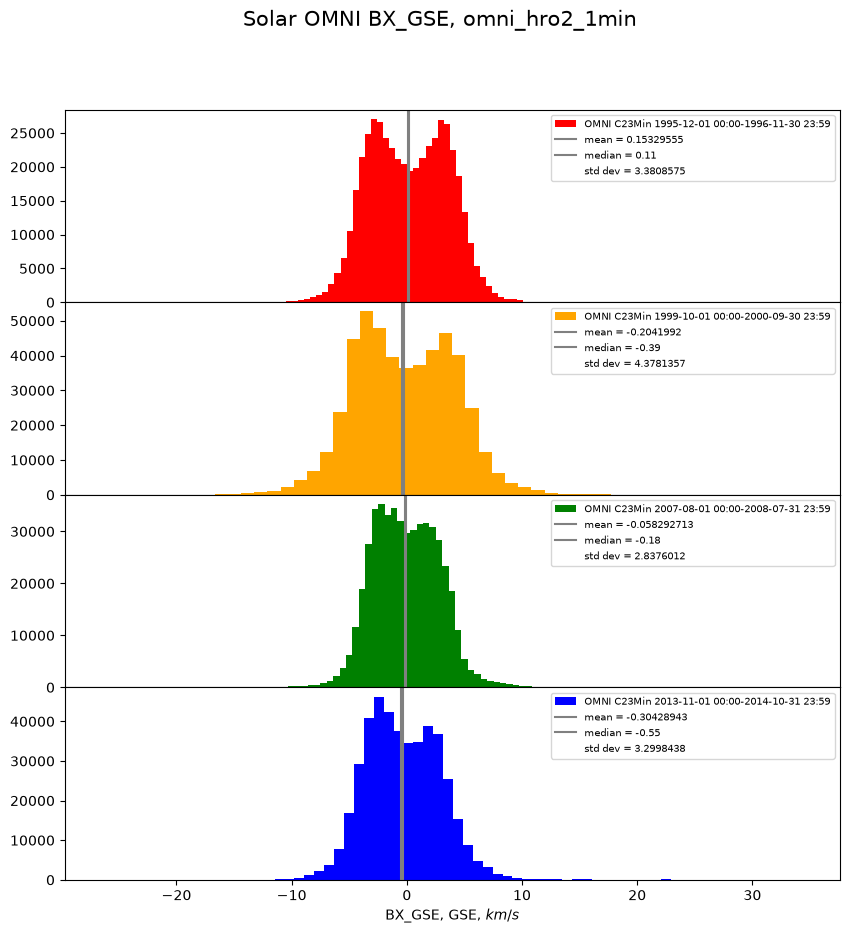

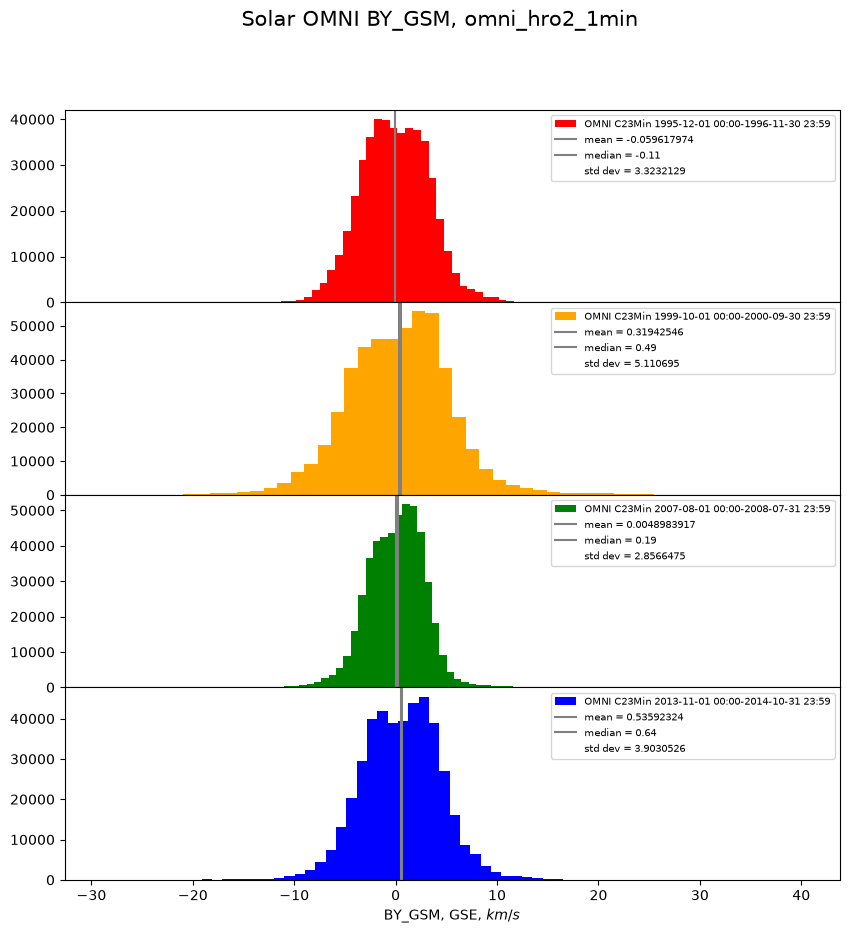

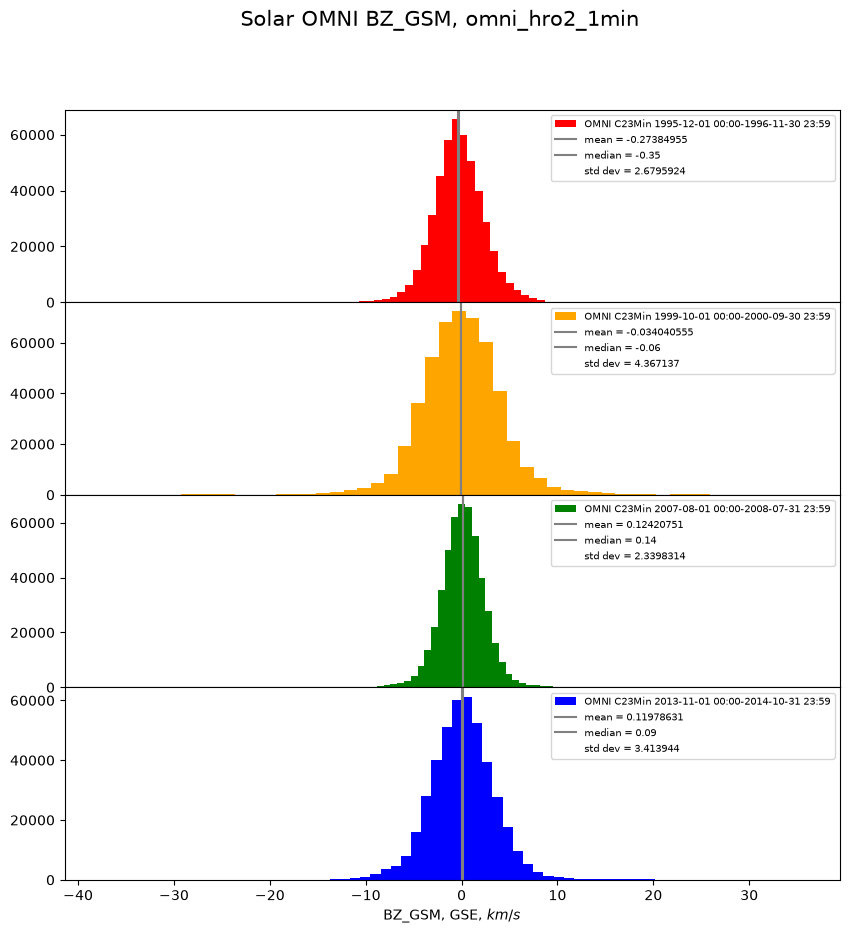

In [58]:
# Histogram formatting settings
Bin = 50
SupTitle = 15
Legend = 7.5
FigSize = (10,10)
LegLoc = 'upper right'
Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM", "BZ_GSM"]
SpaceLR = [100, 5, 5, 5, 5]


for i in range(len(Plotting)):
    #C23 Min
    fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
    fig.subplots_adjust(hspace=0)
    axs[0].hist(OMNIC23Min._data[Plotting[i]], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
    axs[1].hist(OMNIC23Max._data[Plotting[i]], bins = Bin, label = "OMNI C23Min " + startDateC23Max + "-" + endDateC23Max, color="orange")
    axs[2].hist(OMNIC24Min._data[Plotting[i]], bins = Bin, label = "OMNI C23Min " + startDateC24Min + "-" + endDateC24Min, color="green")
    axs[3].hist(OMNIC24Max._data[Plotting[i]], bins = Bin, label = "OMNI C23Min " + startDateC24Max + "-" + endDateC24Max, color="blue")
    plt.suptitle("Solar OMNI "+ Plotting[i] + ", omni_hro2_1min", fontsize = SupTitle)
    # axs[0].title.set_text('OMNI C23 Min')
    # axs[1].title.set_text('OMNI C23 Max')
    # axs[2].title.set_text('OMNI C24 Min')
    # axs[3].title.set_text('OMNI C24 Max')
    # axs[0].set_xlabel(r"TotVsw, GSE, $km/s$")
    # axs[1].set_xlabel(r"TotVsw, GSE, $km/s$")
    # axs[2].set_xlabel(r"TotVsw, GSE, $km/s$")
    axs[3].set_xlabel(Plotting[i] + r", GSE, $km/s$")

    #Mean
    axs[0].axvline(OMNIC23Min._data[Plotting[i]].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data[Plotting[i]].mean()))
    axs[1].axvline(OMNIC23Max._data[Plotting[i]].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data[Plotting[i]].mean()))
    axs[2].axvline(OMNIC24Min._data[Plotting[i]].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data[Plotting[i]].mean()))
    axs[3].axvline(OMNIC24Max._data[Plotting[i]].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data[Plotting[i]].mean()))

    #Median
    axs[0].axvline(OMNIC23Min._data[Plotting[i]].median(), color = "grey", label="median = " + str(OMNIC23Min._data[Plotting[i]].median()))
    axs[1].axvline(OMNIC23Max._data[Plotting[i]].median(), color = "grey", label="median = " + str(OMNIC23Max._data[Plotting[i]].median()))
    axs[2].axvline(OMNIC24Min._data[Plotting[i]].median(), color = "grey", label="median = " + str(OMNIC24Min._data[Plotting[i]].median()))
    axs[3].axvline(OMNIC24Max._data[Plotting[i]].median(), color = "grey", label="median = " + str(OMNIC24Max._data[Plotting[i]].median()))

    #Standard deviation
    axs[0].axvline(OMNIC23Min._data[Plotting[i]].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data[Plotting[i]].std()), alpha = 0)
    axs[1].axvline(OMNIC23Max._data[Plotting[i]].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data[Plotting[i]].std()), alpha = 0)
    axs[2].axvline(OMNIC24Min._data[Plotting[i]].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data[Plotting[i]].std()), alpha = 0)
    axs[3].axvline(OMNIC24Max._data[Plotting[i]].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data[Plotting[i]].std()), alpha = 0)

    axs[0].legend(loc = LegLoc, fontsize = Legend)
    axs[1].legend(loc = LegLoc, fontsize = Legend)
    axs[2].legend(loc = LegLoc, fontsize = Legend)
    axs[3].legend(loc = LegLoc, fontsize = Legend)

    LowerBounds = []
    UpperBounds = []
    LowerBounds.append(min(OMNIC23Min._data[Plotting[i]].values))
    UpperBounds.append(max(OMNIC23Min._data[Plotting[i]].values))
    LowerBounds.append(min(OMNIC23Max._data[Plotting[i]].values))
    UpperBounds.append(max(OMNIC23Max._data[Plotting[i]].values))
    LowerBounds.append(min(OMNIC24Min._data[Plotting[i]].values))
    UpperBounds.append(max(OMNIC24Min._data[Plotting[i]].values))
    LowerBounds.append(min(OMNIC24Max._data[Plotting[i]].values))
    UpperBounds.append(max(OMNIC24Max._data[Plotting[i]].values))

    plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
    plt.savefig(Plotting[i] + ".png")
    plt.show()

# CDFs

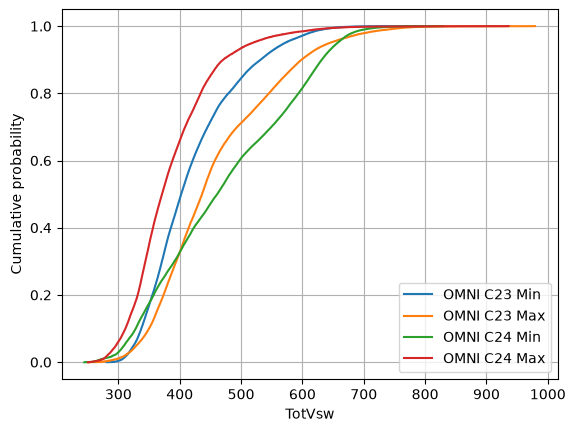

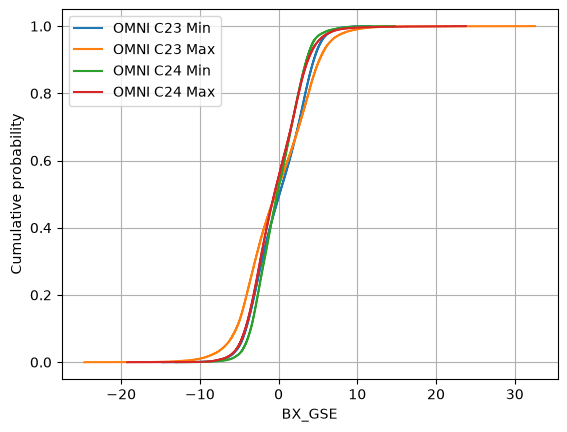

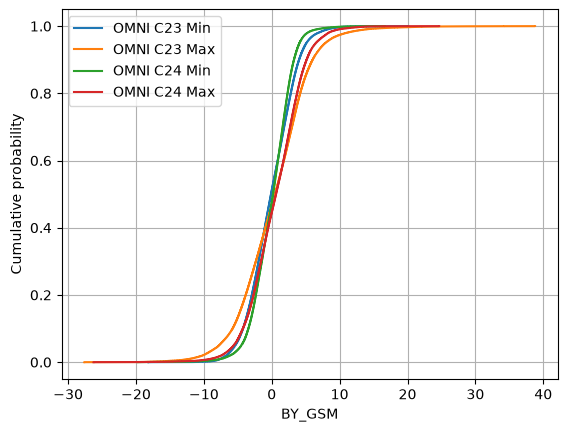

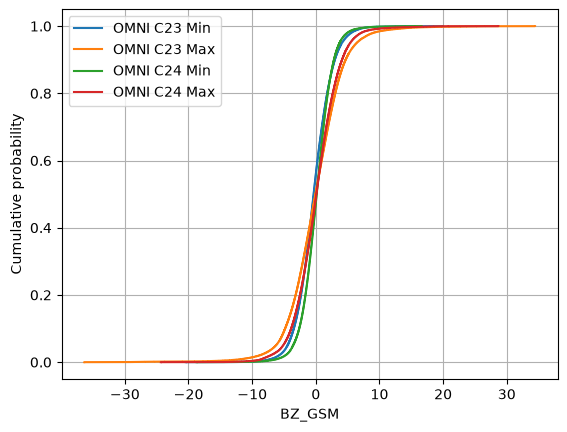

In [ ]:
# CDF Formatting
yLim = [-0.05,1.05]

# Separately
# # C23 Min
# sns.ecdfplot(OMNIC23Min._data["TotVsw"], label="CDF")
# plt.title("OMNI C23 Min, TotVsw")
# plt.xlabel('TotVsw')
# plt.ylabel('Cumulative probability')
# plt.ylim(yLim)
# plt.legend()
# plt.grid(True)
# plt.show()

# # C23 Max
# sns.ecdfplot(OMNIC23Max._data["TotVsw"], label="CDF")
# plt.title("OMNI C23 Max, TotVsw")
# plt.xlabel('TotVsw')
# plt.ylabel('Cumulative probability')
# plt.ylim(yLim)
# plt.legend()
# plt.grid(True)
# plt.show()

# # C24 Min
# sns.ecdfplot(OMNIC24Min._data["TotVsw"], label="CDF")
# plt.title("OMNI C24 Min, TotVsw")
# plt.xlabel('TotVsw')
# plt.ylabel('Cumulative probability')
# plt.ylim(yLim)
# plt.legend()
# plt.grid(True)
# plt.show()

# # C24 Max
# sns.ecdfplot(OMNIC24Max._data["TotVsw"], label="CDF")
# plt.title("OMNI C24 Max, TotVsw")
# plt.xlabel('TotVsw')
# plt.ylabel('Cumulative probability')
# plt.ylim(yLim)
# plt.legend()
# plt.grid(True)
# plt.show()

#All together - TotVsw

# # C23 Min
# sns.ecdfplot(OMNIC23Min._data["TotVsw"], label="OMNI C23 Min")
# # C23 Max
# sns.ecdfplot(OMNIC23Max._data["TotVsw"], label="OMNI C23 Max")
# # C24 Min
# sns.ecdfplot(OMNIC24Min._data["TotVsw"], label="OMNI C24 Min")
# # C24 Max
# sns.ecdfplot(OMNIC24Max._data["TotVsw"], label="OMNI C24 Max")
# plt.xlabel('TotVsw')
# plt.ylabel('Cumulative probability')
# plt.ylim(yLim)
# plt.legend()
# plt.grid(True)
# plt.show()


Plotting = ["TotVsw", "BX_GSE", "BY_GSM", "BZ_GSM"]

for i in range(len(Plotting)):
    # C23 Min
    sns.ecdfplot(OMNIC23Min._data[Plotting[i]], label="OMNI C23 Min")
    # C23 Max
    sns.ecdfplot(OMNIC23Max._data[Plotting[i]], label="OMNI C23 Max")
    # C24 Min
    sns.ecdfplot(OMNIC24Min._data[Plotting[i]], label="OMNI C24 Min")
    # C24 Max
    sns.ecdfplot(OMNIC24Max._data[Plotting[i]], label="OMNI C24 Max")

    plt.xlabel(Plotting[i])
    plt.ylabel('Cumulative probability')
    plt.ylim(yLim)
    plt.legend()
    plt.grid(True)
    plt.show()


In [26]:
def get_quantiles(
    x: pl.Series,
    y: pl.Series,
    size: int = 500, # 500 data points to calculate (default)
    p_range: Tuple[float, float] = (0.0001, 0.9999),) -> Tuple[NDArray, NDArray]: # p_range default set to values used in Tindale and Chapman 2017 to recreate their plots

    x_sorted = np.sort(x.drop_nulls().drop_nans().to_numpy()) # Sort data
    y_sorted = np.sort(y.drop_nulls().drop_nans().to_numpy()) # Sort data

    probabilities = np.linspace(*p_range, size) # make linspace of probabilities in range

    x_quantiles = np.quantile(x_sorted, probabilities) # calculate the quantiles
    y_quantiles = np.quantile(y_sorted, probabilities) # calculate the quantiles

    return x_quantiles, y_quantiles

q = 0.9995 C23
[706.65159448] [874.42949335]
q = 0.9960 C23
[656.03781836] [771.37927173]
q = 0.9980 C24
[742.33779858] [696.45359082]
q = 0.8660 C24
[618.49705005] [455.10978577]


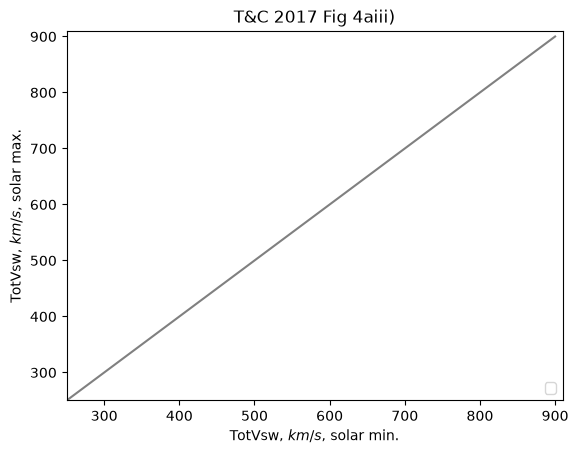

q = 0.9995 C23
[9.78999996] [20.64224444]
q = 0.9960 C23
[8.18000031] [11.72000027]
q = 0.9980 C24
[9.22000027] [13.26000023]
q = 0.8660 C24
[3.17000008] [3.25999999]


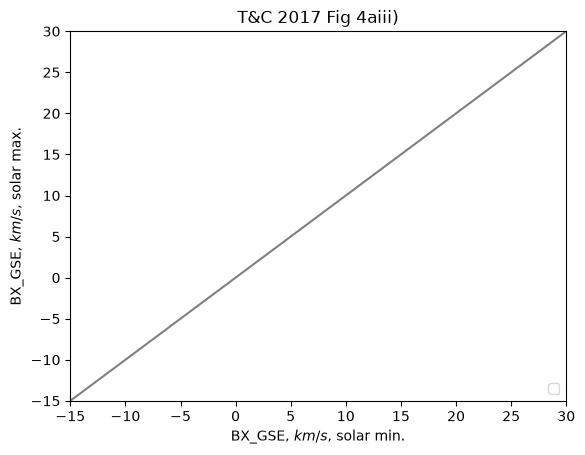

q = 0.9995 C23
[12.84000015] [28.45224539]
q = 0.9960 C23
[9.67000008] [18.77000046]
q = 0.9980 C24
[9.88000011] [13.32999992]
q = 0.8660 C24
[2.8900001] [4.57000017]


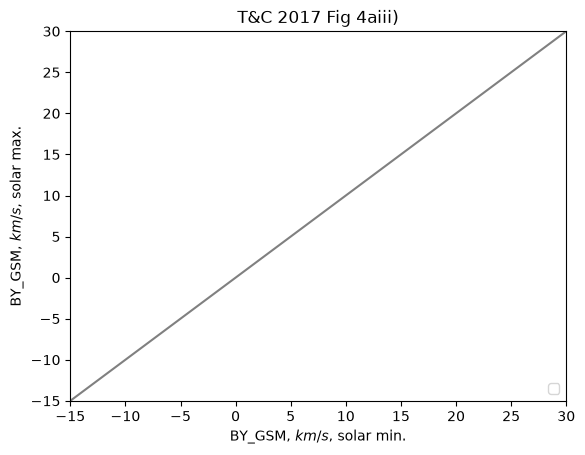

q = 0.9995 C23
[12.60207023] [25.60000038]
q = 0.9960 C23
[7.92000008] [15.78795992]
q = 0.9980 C24
[9.38000011] [16.57941991]
q = 0.8660 C24
[2.46000004] [3.52999997]


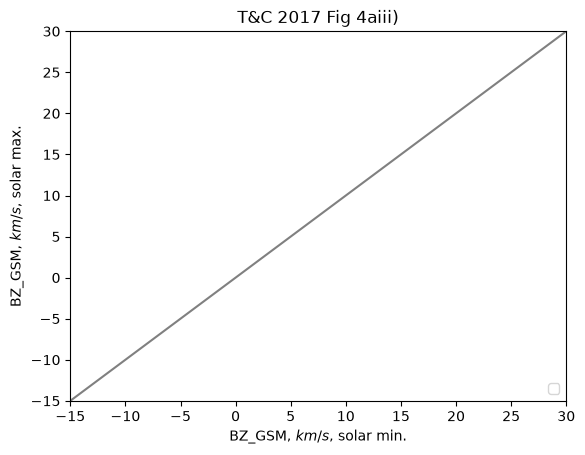

In [ ]:
Plotting = ["TotVsw", "BX_GSE", "BY_GSM", "BZ_GSM"]
Lims = [[250, 910], [-15, 30], [-15, 30], [-15, 30]]
# [0, 40],
QuantilesSpecificC23 = [ [], [], [], []]
QuantilesSpecificC24 = [ [], [], [], []]


for i in range(len(Plotting)):
    # C23
    data_sortedPLSeriesXC23 = pl.Series(OMNIC23Min._data[Plotting[i]]) # make data into a polar series
    data_sortedPLSeriesYC23 = pl.Series(OMNIC23Max._data[Plotting[i]])

    xQuantC23, yQuantC23 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 5000, p_range=(0.0001, 0.9999))

    for j in range(len(QuantilesSpecific[i])):
        xQuantSpecific, yQuantSpecific = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(QuantilesSpecific[i][j], QuantilesSpecific[i][j]))

    # xQ09995, yQ09995 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9995, 0.9995))
    # print("q = 0.9995 C23")
    # print(xQ09995, yQ09995)
    # xQ09960, yQ09960 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9960, 0.9960))
    # print("q = 0.9960 C23")
    # print(xQ09960, yQ09960)

    # C24
    data_sortedPLSeriesXC24 = pl.Series(OMNIC24Min._data[Plotting[i]]) # make data into a polar series
    data_sortedPLSeriesYC24 = pl.Series(OMNIC24Max._data[Plotting[i]])

    xQuantC24, yQuantC24 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 5000, p_range=(0.0001, 0.9999))
    xQ09980, yQ09980 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.9980, 0.9980))
    print("q = 0.9980 C24")
    print(xQ09980, yQ09980)
    xQ08660, yQ08660 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.8660, 0.8660))
    print("q = 0.8660 C24")
    print(xQ08660, yQ08660)

    fig, ax  = plt.subplots(figsize=(5, 5))
    #C23
    plt.scatter(xQuantC23, yQuantC23 , color="red", s=2, label = "C23")
    plt.plot(xQ09980, yQ09980, "o", color="black")
    plt.plot(xQ08660, yQ08660, "o", color="black")

    #C24
    plt.scatter(xQuantC24, yQuantC24, color="blue", s=2, label = "C24")
    plt.plot(xQ09995, yQ09995, "o", color="black")
    plt.plot(xQ09960, yQ09960, "o", color="black")

    x = np.linspace(-100, 900, 2)
    y = x
    plt.plot(x, y, color="grey")
    plt.title("T&C 2017 Fig 4aiii)")
    plt.legend(loc="lower right")
    plt.xlabel(Plotting[i] + r", $km/s$, solar min.")
    plt.ylabel(Plotting[i] + r", $km/s$, solar max.")
    plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
    plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
    plt.show()

q = 0.9995 C23
[706.65159448] [874.42949335]
q = 0.9960 C23
[656.03781836] [771.37927173]
q = 0.9980 C24
[742.33779858] [696.45359082]
q = 0.8660 C24
[618.49705005] [455.10978577]


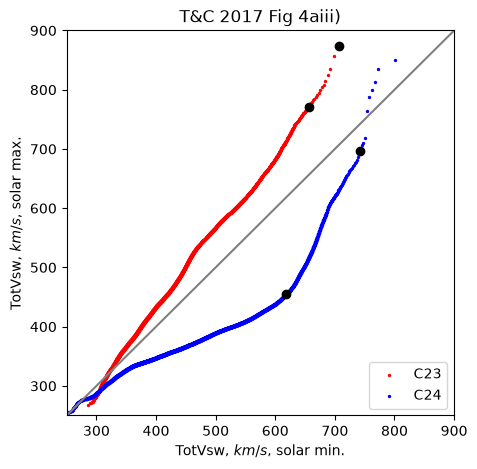

In [ ]:

# C23
data_sortedPLSeriesXC23 = pl.Series(OMNIC23Min._data["TotVsw"]) # make data into a polar series
data_sortedPLSeriesYC23 = pl.Series(OMNIC23Max._data["TotVsw"])

xQuantC23, yQuantC23 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 5000, p_range=(0.0001, 0.9999))
xQ09995, yQ09995 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9995, 0.9995))
print("q = 0.9995 C23")
print(xQ09995, yQ09995)
xQ09960, yQ09960 = get_quantiles(data_sortedPLSeriesXC23, data_sortedPLSeriesYC23, size = 1, p_range=(0.9960, 0.9960))
print("q = 0.9960 C23")
print(xQ09960, yQ09960)

# C24
data_sortedPLSeriesXC24 = pl.Series(OMNIC24Min._data["TotVsw"]) # make data into a polar series
data_sortedPLSeriesYC24 = pl.Series(OMNIC24Max._data["TotVsw"])

xQuantC24, yQuantC24 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 5000, p_range=(0.0001, 0.9999))
xQ09980, yQ09980 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.9980, 0.9980))
print("q = 0.9980 C24")
print(xQ09980, yQ09980)
xQ08660, yQ08660 = get_quantiles(data_sortedPLSeriesXC24, data_sortedPLSeriesYC24, size = 1, p_range=(0.8660, 0.8660))
print("q = 0.8660 C24")
print(xQ08660, yQ08660)

fig, ax  = plt.subplots(figsize=(5, 5))
#C23
plt.scatter(xQuantC23, yQuantC23 , color="red", s=2, label = "C23")
plt.plot(xQ09980, yQ09980, "o", color="black")
plt.plot(xQ08660, yQ08660, "o", color="black")

#C24
plt.scatter(xQuantC24, yQuantC24, color="blue", s=2, label = "C24")
plt.plot(xQ09995, yQ09995, "o", color="black")
plt.plot(xQ09960, yQ09960, "o", color="black")

x = np.linspace(250, 900, 30)
y = x
plt.plot(x, y, color="grey")
plt.title("T&C 2017 Fig 4aiii)")
plt.legend(loc="lower right")
plt.xlabel(r"TotVsw, $km/s$, solar min.")
plt.ylabel(r"TotVsw, $km/s$, solar max.")
plt.xlim(250,900)
plt.ylim(250,900)
plt.show()

# Archived code

In [ ]:
# import cdflib
# cdf_file = cdflib.CDF('wi_k0_swe_19951201_v02.cdf')
# cdf_file.cdf_info()
# print(cdf_file.varget)

# import pandas as pd
# cdf_fileDF = pd.DataFrame(cdf_file)
# print(cdf_fileDF)

# import warnings
# warnings.filterwarnings("ignore")
# WIND = TimeSeries(cdf_fileDF)


In [ ]:
# import cdflib

# # CDFmerge
# # One file
# # cdf_file = cdflib.CDF("wi_k0_swe_19951201_v02.cdf")
# # cdf_file.cdf_info()

# # #  For multiple files
# # cdf_file = cdflib.CDF("wi_k0_swe_19951201_v02.cdf")
# # cdf_file2 = cdflib.CDF("wi_k0_swe_19951202_v02.cdf")

# directory = "."

# for file in os.listdir(directory):
#     filename = os.fsdecode(file)
#     if filename.endswith(".cdf") or filename.endswith(".py"): 
#         print(os.path.join(directory, filename))
#         FileAsCDF = cdflib.xarray.cdf_to_xarray(filename, to_datetime=True, to_unixtime=False, fillval_to_nan=False)
#         FileAsDF = FileAsCDF.to_dataframe


#         continue
#     else:
#         continue


# # X1 = cdflib.xarray.cdf_to_xarray("wi_k0_swe_19951201_v02.cdf", to_datetime=True, to_unixtime=False, fillval_to_nan=False)
# # X2 = cdflib.xarray.cdf_to_xarray("wi_k0_swe_19951202_v02.cdf", to_datetime=True, to_unixtime=False, fillval_to_nan=False)

# # # import xr.DataArray

# # giveMe = X1.to_dataframe

# # print(giveMe)


In [ ]:

# # print(cdf_file.cdf_info)
# VswComponents = cdf_file.varget("V_GSM")#, startrec=0, endrec=150)
# print(VswComponents[1][2])

# TotVsw = []
# for a in range(len(VswComponents)):
#     # Calculated = )
#     # print(Calculated)
#     TotVsw.append( np.sqrt(VswComponents[a][0]**2 + VswComponents[a][1]**2 + VswComponents[a][2]**2) )

# print(len(TotVsw))
# # print(TotVsw)

# Time = cdf_file.varget("Epoch")#, startrec=0, endrec=150)
# # print(Time[1])

# DateTime = []
# for b in range(len(Time)):
#     DateTime.append (((Time[b]/1000)/3600))# /1000 milliseconds to seconds, /3600 to hours, /24 to days
# print(len(DateTime))
# # print(DateTime[0])


In [ ]:
# fig, ax = plt.subplots()
# plt.plot(DateTime, TotVsw)
# # plt.legend(loc="upper right")
# # plt.ylim(-450,900)

In [ ]:
# # import matplotlib.pyplot as plt
# # import numpy as np

# # create some randomly ddistributed data:
# data = TotVsw

# # sort the data:
# data_sorted = np.sort(data)

# # calculate the proportional values of samples
# p = 1. * np.arange(len(data)) / (len(data) - 1)

# # plot the sorted data:
# fig = plt.figure()
# ax1 = fig.add_subplot(121)
# ax1.plot(p, data_sorted)
# ax1.set_xlabel('$p$')
# ax1.set_ylabel('$x$')

# ax2 = fig.add_subplot(122)
# ax2.plot(data_sorted, p)
# ax2.set_xlabel('$x$')
# ax2.set_ylabel('$p$')
# plt.tight_layout()

In [ ]:
# fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))



# # total wind speed
# WIND._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
# ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
# # plt.axhline(400, ls="dashed")

# # components of wind speed
# WIND._data["V_GSM_0"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
# ax[1].set_ylabel("V_GSM_0 V$_{SW}$ (km/s)")

# # components of wind speed
# WIND._data["V_GSM_1"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
# ax[2].set_ylabel("V_GSM_1 V$_{SW}$ (km/s)")

# # components of wind speed
# WIND._data["V_GSM_2"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar wind is mostly radial/along the Parker spiral
# ax[3].set_ylabel("V_GSM_2 V$_{SW}$ (km/s)")



# for aa in ax:
#     aa.legend(loc="upper left")
#     # aa.axvline("2022-01-29 00:00", color='k')
#     # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
#     # aa.set_ylim(-400,400)

# # ax[0].set_xlim(psp_spc.time[0].datetime, psp_spc.time[-1].datetime)
# # ax[4].set_xlabel("Time")
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.02)

# Archive

In [ ]:
# Histogram formatting settings
# Bin = 50
# SupTitle = 15
# Legend = 10
# FigSize = (10,10)
# SpaceLRVsw = 100
# SpaceLRB = 5
# LegLoc = 'upper right'
# Plotting = ["TotVsw", "BMag", "BX_GSE", "BY_GSM", "BZ_GSM"]





# #C23 Min
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["TotVsw"], bins = Bin, label = "OMNI C23Min " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Solar OMNI Velocity, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"TotVsw, GSE, $km/s$")
# # axs[1].set_xlabel(r"TotVsw, GSE, $km/s$")
# # axs[2].set_xlabel(r"TotVsw, GSE, $km/s$")
# axs[3].set_xlabel(r"TotVsw, GSE, $km/s$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["TotVsw"].mean()))
# axs[1].axvline(OMNIC23Max._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["TotVsw"].mean()))
# axs[2].axvline(OMNIC24Min._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["TotVsw"].mean()))
# axs[3].axvline(OMNIC24Max._data["TotVsw"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["TotVsw"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["TotVsw"].median()))
# axs[1].axvline(OMNIC23Max._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["TotVsw"].median()))
# axs[2].axvline(OMNIC24Min._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["TotVsw"].median()))
# axs[3].axvline(OMNIC24Max._data["TotVsw"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["TotVsw"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["TotVsw"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["TotVsw"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["TotVsw"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["TotVsw"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["TotVsw"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC23Min._data["TotVsw"].values))
# LowerBounds.append(min(OMNIC23Max._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC23Max._data["TotVsw"].values))
# LowerBounds.append(min(OMNIC24Min._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC24Min._data["TotVsw"].values))
# LowerBounds.append(min(OMNIC24Max._data["TotVsw"].values))
# UpperBounds.append(max(OMNIC24Max._data["TotVsw"].values))

# plt.xlim(min(LowerBounds) - SpaceLRVsw, max(UpperBounds) + SpaceLRVsw)
# plt.savefig("TotVsw_GSE.png")
# plt.show()


# #C23 Max
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["BX_GSE"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["BX_GSE"], bins = Bin, label = "OMNI C23Max " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["BX_GSE"], bins = Bin, label = "OMNI C24Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["BX_GSE"], bins = Bin, label = "OMNI C24Max " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Magnetic field, Bx GSE/GSM, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"Bx, GSE/GSM, $nT$")
# # axs[1].set_xlabel(r"Bx, GSE/GSM, $nT$")
# # axs[2].set_xlabel(r"Bx, GSE/GSM, $nT$")
# axs[3].set_xlabel(r"Bx, GSE/GSM, $nT$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["BX_GSE"].mean()))
# axs[1].axvline(OMNIC23Max._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["BX_GSE"].mean()))
# axs[2].axvline(OMNIC24Min._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["BX_GSE"].mean()))
# axs[3].axvline(OMNIC24Max._data["BX_GSE"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["BX_GSE"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["BX_GSE"].median()))
# axs[1].axvline(OMNIC23Max._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["BX_GSE"].median()))
# axs[2].axvline(OMNIC24Min._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["BX_GSE"].median()))
# axs[3].axvline(OMNIC24Max._data["BX_GSE"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["BX_GSE"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["BX_GSE"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["BX_GSE"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["BX_GSE"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["BX_GSE"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["BX_GSE"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC23Min._data["BX_GSE"].values))
# LowerBounds.append(min(OMNIC23Max._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC23Max._data["BX_GSE"].values))
# LowerBounds.append(min(OMNIC24Min._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC24Min._data["BX_GSE"].values))
# LowerBounds.append(min(OMNIC24Max._data["BX_GSE"].values))
# UpperBounds.append(max(OMNIC24Max._data["BX_GSE"].values))


# plt.xlim(min(LowerBounds) - SpaceLRB, max(UpperBounds) + SpaceLRB)
# plt.savefig("MagFieldX_GSE_GSM.png")
# plt.show()


# #C24 Min
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["BY_GSM"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["BY_GSM"], bins = Bin, label = "OMNI C23Max " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["BY_GSM"], bins = Bin, label = "OMNI C24Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["BY_GSM"], bins = Bin, label = "OMNI C24Max " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Magnetic field, By, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"By, GSM, $nT$")
# # axs[1].set_xlabel(r"By, GSM, $nT$")
# # axs[2].set_xlabel(r"By, GSM, $nT$")
# axs[3].set_xlabel(r"By, GSM, $nT$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["BY_GSM"].mean()))
# axs[1].axvline(OMNIC23Max._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["BY_GSM"].mean()))
# axs[2].axvline(OMNIC24Min._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["BY_GSM"].mean()))
# axs[3].axvline(OMNIC24Max._data["BY_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["BY_GSM"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["BY_GSM"].median()))
# axs[1].axvline(OMNIC23Max._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["BY_GSM"].median()))
# axs[2].axvline(OMNIC24Min._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["BY_GSM"].median()))
# axs[3].axvline(OMNIC24Max._data["BY_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["BY_GSM"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["BY_GSM"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["BY_GSM"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["BY_GSM"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["BY_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["BY_GSM"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC23Min._data["BY_GSM"].values))
# LowerBounds.append(min(OMNIC23Max._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC23Max._data["BY_GSM"].values))
# LowerBounds.append(min(OMNIC24Min._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC24Min._data["BY_GSM"].values))
# LowerBounds.append(min(OMNIC24Max._data["BY_GSM"].values))
# UpperBounds.append(max(OMNIC24Max._data["BY_GSM"].values))

# plt.xlim(min(LowerBounds) - SpaceLRB, max(UpperBounds)+ SpaceLRB)
# plt.savefig("MagFieldY_GSM.png")
# plt.show()


# #C24 Max
# fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
# fig.subplots_adjust(hspace=0)
# axs[0].hist(OMNIC23Min._data["BZ_GSM"], bins = Bin, label = "OMNI C23Min " + startDateC23Min + "-" + endDateC23Min, color="red")
# axs[1].hist(OMNIC23Max._data["BZ_GSM"], bins = Bin, label = "OMNI C23Max " + startDateC23Max + "-" + endDateC23Max, color="orange")
# axs[2].hist(OMNIC24Min._data["BZ_GSM"], bins = Bin, label = "OMNI C24Min " + startDateC24Min + "-" + endDateC24Min, color="green")
# axs[3].hist(OMNIC24Max._data["BZ_GSM"], bins = Bin, label = "OMNI C24Max " + startDateC24Max + "-" + endDateC24Max, color="blue")
# plt.suptitle("Magnetic field, Bz, omni_hro2_1min", fontsize = SupTitle)
# # axs[0].title.set_text('OMNI C23 Min')
# # axs[1].title.set_text('OMNI C23 Max')
# # axs[2].title.set_text('OMNI C24 Min')
# # axs[3].title.set_text('OMNI C24 Max')
# # axs[0].set_xlabel(r"Bz, GSM, $nT$")
# # axs[1].set_xlabel(r"Bz, GSM, $nT$")
# # axs[2].set_xlabel(r"Bz, GSM, $nT$")
# axs[3].set_xlabel(r"Bz, GSM, $nT$")

# #Mean
# axs[0].axvline(OMNIC23Min._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Min._data["BZ_GSM"].mean()))
# axs[1].axvline(OMNIC23Max._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC23Max._data["BZ_GSM"].mean()))
# axs[2].axvline(OMNIC24Min._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Min._data["BZ_GSM"].mean()))
# axs[3].axvline(OMNIC24Max._data["BZ_GSM"].mean(), color = "grey", label="mean = " + str(OMNIC24Max._data["BZ_GSM"].mean()))

# #Median
# axs[0].axvline(OMNIC23Min._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Min._data["BZ_GSM"].median()))
# axs[1].axvline(OMNIC23Max._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC23Max._data["BZ_GSM"].median()))
# axs[2].axvline(OMNIC24Min._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Min._data["BZ_GSM"].median()))
# axs[3].axvline(OMNIC24Max._data["BZ_GSM"].median(), color = "grey", label="median = " + str(OMNIC24Max._data["BZ_GSM"].median()))

# #Standard deviation
# axs[0].axvline(OMNIC23Min._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Min._data["BZ_GSM"].std()), alpha = 0)
# axs[1].axvline(OMNIC23Max._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC23Max._data["BZ_GSM"].std()), alpha = 0)
# axs[2].axvline(OMNIC24Min._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Min._data["BZ_GSM"].std()), alpha = 0)
# axs[3].axvline(OMNIC24Max._data["BZ_GSM"].std(), color = "grey", label="std dev = " + str(OMNIC24Max._data["BZ_GSM"].std()), alpha = 0)

# axs[0].legend(loc = LegLoc, fontsize = Legend)
# axs[1].legend(loc = LegLoc, fontsize = Legend)
# axs[2].legend(loc = LegLoc, fontsize = Legend)
# axs[3].legend(loc = LegLoc, fontsize = Legend)

# LowerBounds = []
# UpperBounds = []
# LowerBounds.append(min(OMNIC23Min._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC23Min._data["BZ_GSM"].values))
# LowerBounds.append(min(OMNIC23Max._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC23Max._data["BZ_GSM"].values))
# LowerBounds.append(min(OMNIC24Min._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC24Min._data["BZ_GSM"].values))
# LowerBounds.append(min(OMNIC24Max._data["BZ_GSM"].values))
# UpperBounds.append(max(OMNIC24Max._data["BZ_GSM"].values))

# plt.xlim(min(LowerBounds) - SpaceLRB, max(UpperBounds) + SpaceLRB)
# plt.savefig("MagFieldZ_GSM.png")
# plt.show()